In [1]:
import matplotlib.pyplot as plt
import numpy as np

from MemriNeurons.snn import LIFNeuron, Astrocyte
from simulator.src import BoardSimulator # коннект к плате
from MemriNeurons.cores import HardCore # ядро

## Работа с кроссбаром

In [2]:
colors = ['red', 'violet', 'green', 'black', 'blue', 'orange', 'magenta', 'brown', 'cyan'] # цвета для отрисовки графиков

In [3]:
# board connection
# com_port = '/dev/tty.usbmodem5A4F0105071'
# CONN = RPI_modes_ELBEAR(com_port)

# подключаем плату (симулятор)
CONN = BoardSimulator()
_ = CONN.connect('simulator')
# создаем обработчик ядра
device = HardCore(CONN)

simulator_settings.ini существует в текущей папке
Ошибка в alter_memristors_table:  memristors


Weight range for matrix multiplication loop: 0.003290027269341173-0.05609735781444694


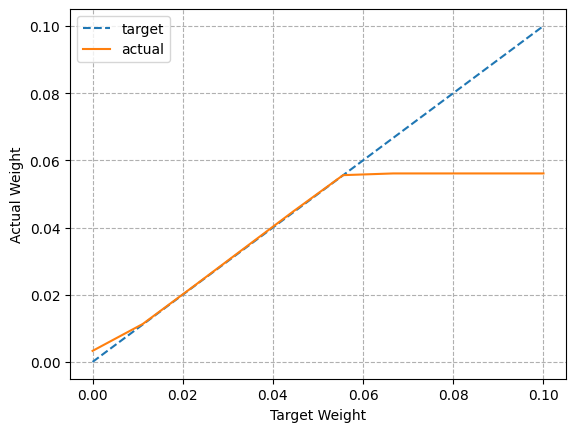

In [4]:
if 1: # диапазон весов
    BL, WL = 0, 1 # координаты ячейки
    device.set_mvm()
    weight_range = np.linspace(0, 0.1, 10)
    actual_weights = []
    for weight_value in weight_range:
        _ = device.write_weight(BL, WL, weight_value)
        actual_weights.append(device.read_one_weight(BL, WL)[0])
    print(f'Weight range for matrix multiplication loop: {min(actual_weights)}-{max(actual_weights)}')
    plt.plot(weight_range, weight_range, '--', label='target')
    plt.plot(weight_range, actual_weights, label='actual')
    plt.grid(True, linestyle='--')
    plt.xlabel('Target Weight')
    plt.ylabel('Actual Weight')
    plt.legend()
    plt.show()
    device.set_wr()
    min_weight = min(actual_weights)
    max_weight = max(actual_weights)

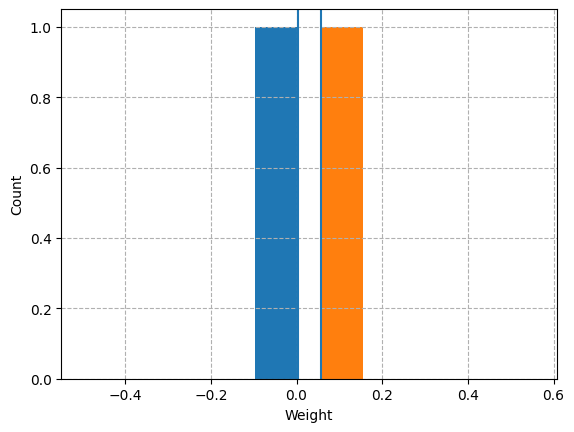

Weight range for matrix multiplication loop: 0.003290027269341173-0.05609735781444694


In [5]:
if 1: # разброс минимального и максимального веса 
    device.set_mvm()
    min_weight_write = []
    for _ in range(1):
        _ = device.write_weight(BL, WL, min(weight_range))
        min_weight_write.append(device.read_one_weight(BL, WL)[0])
    max_weight_write = []
    for _ in range(1):
        _ = device.write_weight(BL, WL, max(weight_range))
        max_weight_write.append(device.read_one_weight(BL, WL)[0])
    plt.hist(min_weight_write)
    plt.hist(max_weight_write)
    plt.axvline(np.mean(min_weight_write))
    plt.axvline(np.mean(max_weight_write))
    plt.grid(True, linestyle='--')
    plt.xlabel('Weight')
    plt.ylabel('Count')
    plt.show()
    print(f'Weight range for matrix multiplication loop: {np.mean(min_weight_write)}-{np.mean(max_weight_write)}')
    device.set_wr()

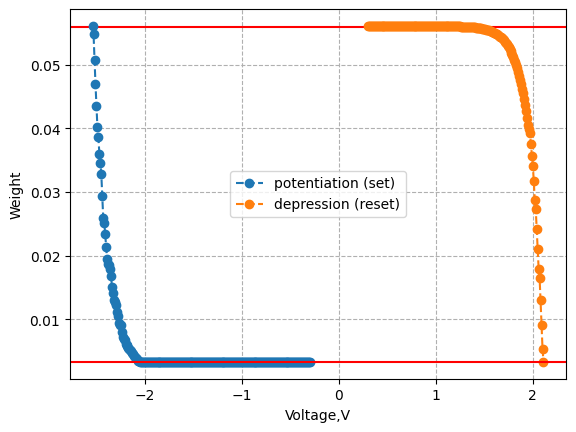

In [6]:
if 1: # запись минимального и максимального веса
    # запишем синаптический вес
    BL, WL = 0, 0 # координаты ячейки
    WEIGHT = 0.0
    device.set_mvm()
    _, weight_history, vol_history = device.write_weight(BL, WL, WEIGHT)

    WEIGHT = 0.056
    device.set_mvm()
    _, weight_history_set, vol_history_set = device.write_weight(BL, WL, WEIGHT)
    plt.axhline(WEIGHT, color='r')

    WEIGHT = 0.0033
    device.set_mvm()
    _, weight_history_reset, vol_history_reset = device.write_weight(BL, WL, WEIGHT)

    plt.plot(vol_history_set, weight_history_set, '--o', label='potentiation (set)')
    plt.plot(vol_history_reset, weight_history_reset, '--o', label='depression (reset)')

    plt.axhline(WEIGHT, color='r')
    plt.xlabel('Voltage,V')
    plt.ylabel('Weight')
    plt.grid(True, linestyle='--')
    plt.legend()
    plt.show()
    device.set_wr()

In [7]:
assert 1

## STDP

In [8]:
def write_weight(BL, WL, WEIGHT):   
    # запишем синаптический вес
    device.set_mvm()
    _ = device.write_weight(BL, WL, WEIGHT)
    #print(f'Weight {BL}, {WL} = {device.read_one_weight(BL, WL)[0]}')
    device.set_wr()

In [9]:
BL, WL = 0, 0 # координаты ячейки

In [10]:
def plot_stdp(WEIGHTS, count, pot, table):
    for i, WEIGHT in enumerate(WEIGHTS):
        weight_diff = []
        for voltage in table:
            weight_diff_current = []
            for _ in range(count):
                write_weight(BL, WL, WEIGHT)
                device.set_mvm()
                previous_weight = device.read_one_weight(BL, WL)[0]
                device.set_wr()
                _ = device.apply_voltage(voltage, pot, BL, WL)
                device.set_mvm()
                current_weight = device.read_one_weight(BL, WL)[0]
                device.set_wr()
                weight_diff_current.append(current_weight-previous_weight)
            weight_diff.append(np.mean(weight_diff_current))
        plt.plot([i for i in range(len(weight_diff))], weight_diff[::-1], 'o', color=colors[i], label=f'W={round(WEIGHT,3)}')
        plt.plot([i for i in range(len(weight_diff))], weight_diff[::-1], '--', color=colors[i])

    plt.legend()
    plt.grid(True, linestyle='--')
    plt.xlabel('Разница трейсов')
    plt.ylabel('Изменение веса')
    if pot:
        plt.title('Потенциация')
    else:
        plt.title('Депрессия')

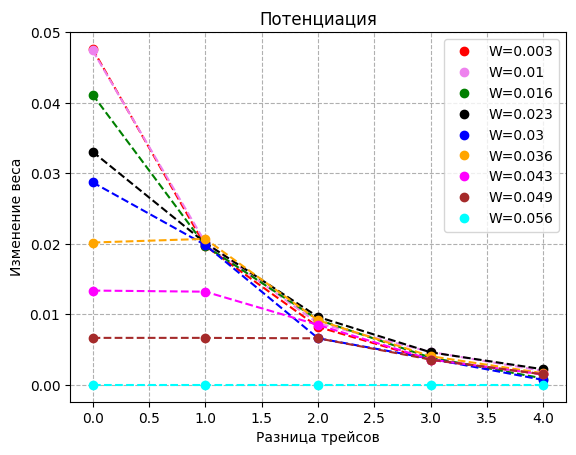

In [11]:
# потенциация
vol_max_pot = 2.85
vol_min_pot = 2.4
trace_deep: int = 5 # ширина трейса (в импульсах)
potentiation_table = np.linspace(vol_min_pot, vol_max_pot, trace_deep)
if 1:
    WEIGHTS = np.linspace(min_weight, max_weight, len(colors))
    count = 1
    pot = 1 # 0 for dep
    plot_stdp(WEIGHTS, count, pot, potentiation_table)


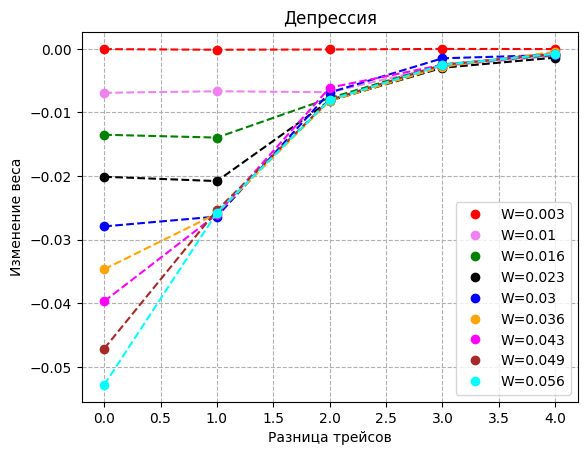

In [12]:
# депрессия
vol_max_dep = 2.5
vol_min_dep = 1.9
depression_table = np.linspace(vol_min_dep, vol_max_dep, trace_deep) 
if 1:
    WEIGHTS = np.linspace(min_weight, max_weight, len(colors))
    count = 1
    pot = 0 # 0 for dep
    plot_stdp(WEIGHTS, count, pot, depression_table)

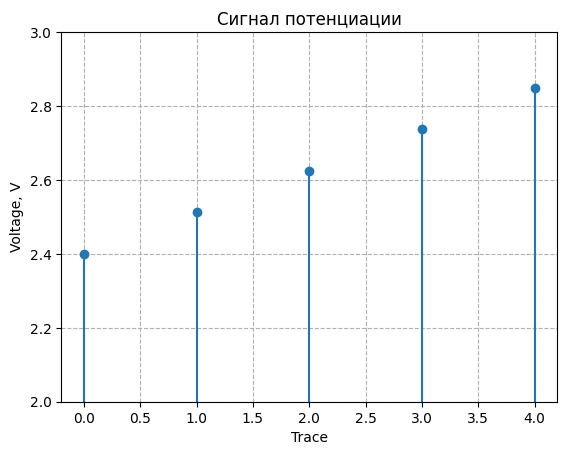

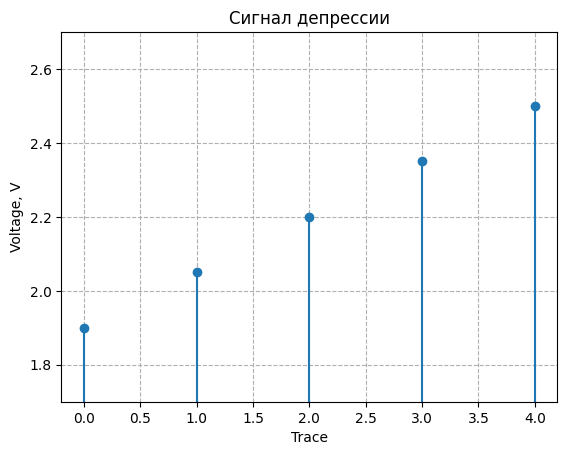

In [13]:
# соответствие трейса и амплитуд потенциации и депрессии
plt.stem(potentiation_table)
plt.ylim([2, 3])
plt.xlabel('Trace')
plt.ylabel('Voltage, V')
plt.grid(True, linestyle='--')
plt.title('Сигнал потенциации')
plt.show()
plt.stem(depression_table)
plt.ylim([1.7, 2.7])
plt.xlabel('Trace')
plt.ylabel('Voltage, V')
plt.grid(True, linestyle='--')
plt.title('Сигнал депрессии')
plt.show()

In [14]:
assert 1

## Пример 1 - связь пре и пост нейрона

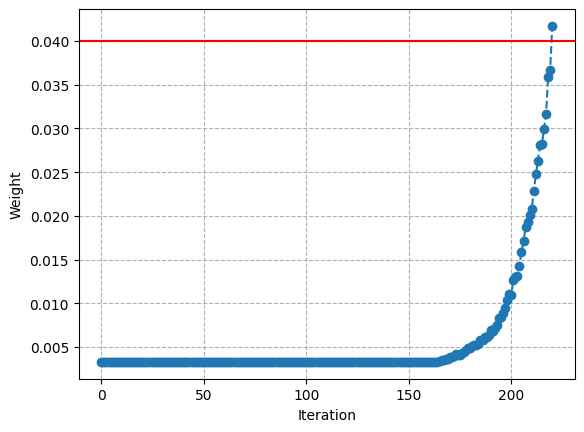

Weight 0, 0 = 0.04172467028027599


In [15]:
# запишем синаптический вес
BL, WL = 0, 0 # координаты ячейки
#WEIGHT = np.random.uniform(0, 0.05)
WEIGHT = 0.04
device.set_mvm()
_, weight_history, vol_history = device.write_weight(BL, WL, WEIGHT)
plt.plot(weight_history, '--o')
plt.axhline(WEIGHT, color='r')
plt.xlabel('Iteration')
plt.ylabel('Weight')
plt.grid(True, linestyle='--')
plt.show()
print(f'Weight {BL}, {WL} = {device.read_one_weight(BL, WL)[0]}')
device.set_wr()

my_neuron Трешхолд basic 0.05
my_neuron Трешхолд basic 0.07258427
my_neuron синапс 0 - потенциация
my_neuron синапс 0 - депрессия


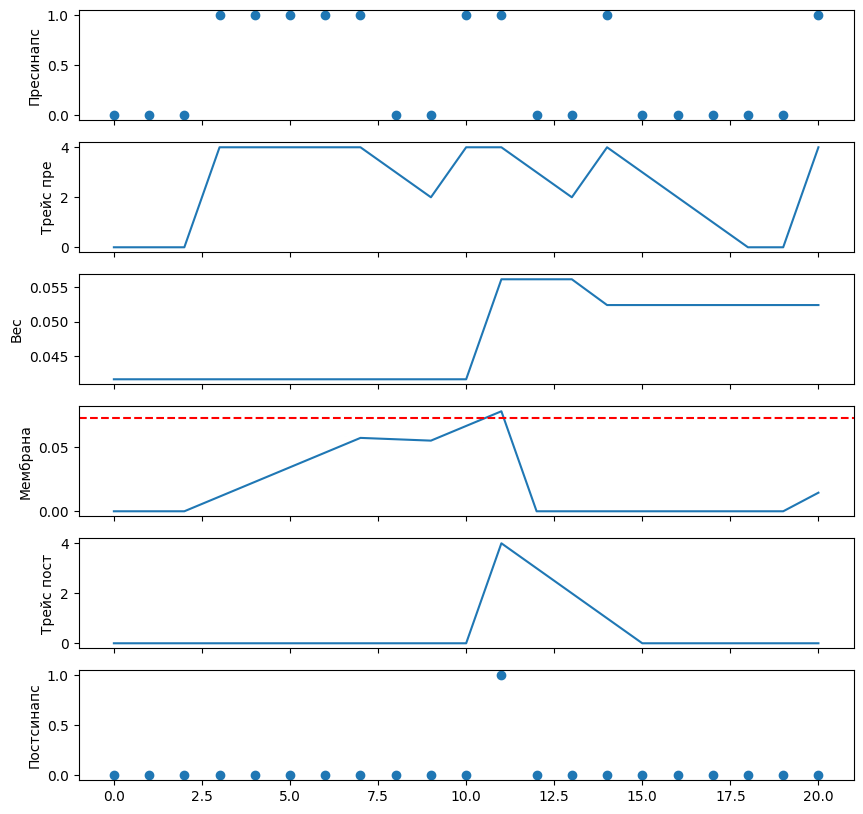

In [16]:
# входные данные
input_data = np.array([0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1]) # потенциация и депрессия (1 мс)
input_data = np.expand_dims(input_data, axis=1)

# хранилище выходных данных
output_data = []

# нейрон
neuron = LIFNeuron(device, 0, 1, name='my_neuron') # device, wl, synapses_amount

# настройка параметров нейрона
treshold = 0.07258427 # трешхолд (по умолчанию)
leakage = 0.00106742 # утечка

neuron.basic_tresh = treshold
neuron.change_membrain_tresh(mode='basic')
neuron.leakage = leakage

neuron.change_trace_deep(4)

# рабочий цикл
for item in input_data:
    output_data.append(neuron.set_input_spike(item))

# отрисовка
fig, ax = plt.subplots(6, figsize=(10,10), sharex=True)

ax[0].plot(input_data, 'o')
ax[0].set_ylabel('Пресинапс')

ax[1].plot(neuron.synapses[0].trace_history)
ax[1].set_ylabel('Трейс пре')

ax[2].plot(neuron.synapses[0].weight_history)
ax[2].set_ylabel('Вес')

ax[3].plot(neuron.membrain_history)
ax[3].axhline(neuron.basic_tresh, linestyle='--', color='red')
ax[3].set_ylabel('Мембрана')

ax[4].plot(neuron.trace_history)
ax[4].set_ylabel('Трейс пост')

ax[-1].plot(output_data, 'o')
ax[-1].set_ylabel('Постсинапс')

plt.show()

## Пример 2 - Один нейрон и один астроцит

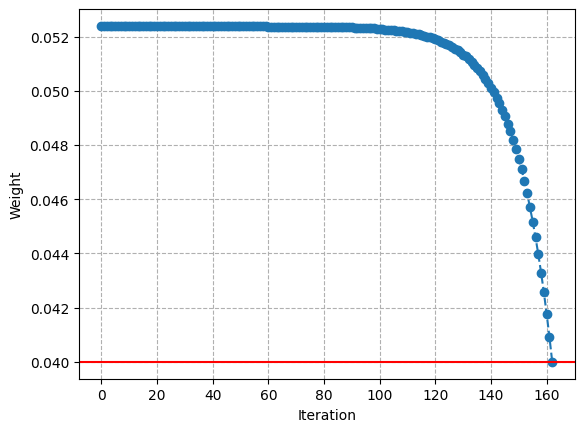

Weight 0, 0 = 0.03999956364112391


In [17]:
# запишем синаптический вес
BL, WL = 0, 0 # координаты ячейки
#WEIGHT = np.random.uniform(0, 0.05)
WEIGHT = 0.04
device.set_mvm()
_, weight_history, _ = device.write_weight(BL, WL, WEIGHT)
plt.plot(weight_history, '--o')
plt.axhline(WEIGHT, color='r')
plt.xlabel('Iteration')
plt.ylabel('Weight')
plt.grid(True, linestyle='--')
plt.show()
print(f'Weight {BL}, {WL} = {device.read_one_weight(BL, WL)[0]}')
device.set_wr()

Neuron Трешхолд basic 0.05
Neuron синапс 0 - потенциация
Neuron синапс 0 - депрессия
Neuron Трешхолд gain 0.015
Neuron синапс 0 - потенциация
Neuron Трешхолд basic 0.05
Neuron синапс 0 - потенциация


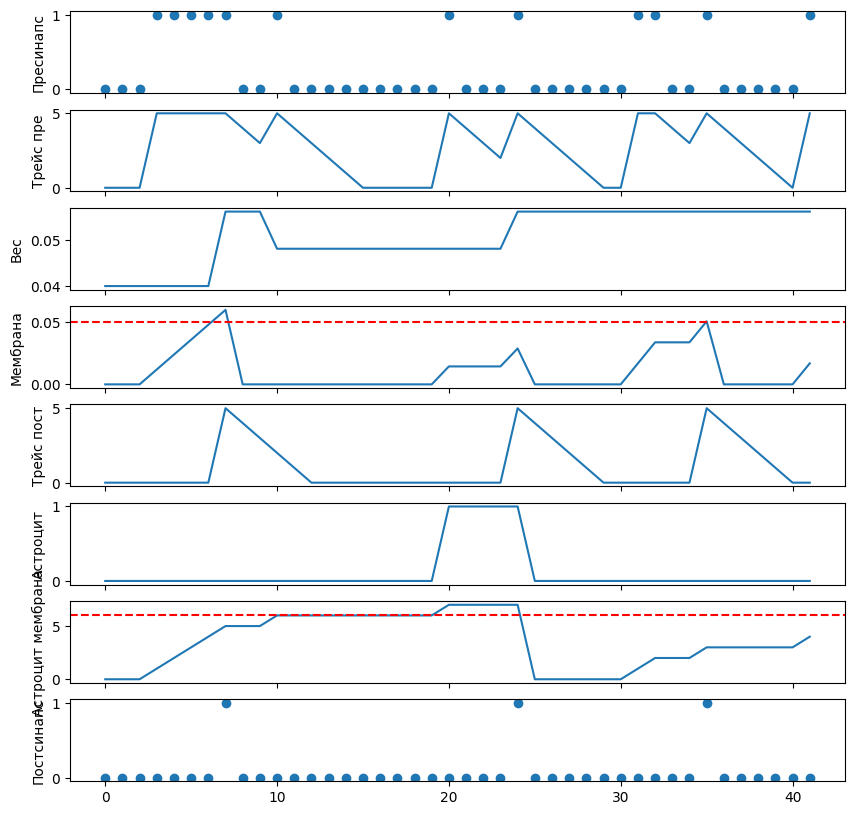

In [18]:
# входные данные
input_data = np.array([0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1])
input_data = np.expand_dims(input_data, axis=1)

# хранилище выходных данных
output_data = []

# нейрон
neuron = LIFNeuron(device, 0, 1)

# астроцит
astrocyte = Astrocyte()
astrocyte.set_controlled_membrains([neuron, ])

# настройка астроцита
astrocyte.tresh = 6
astrocyte.active_time = 5

# рабочий цикл
for item in input_data:
    astrocyte.set_input_spikes(item)
    output_data.append(neuron.set_input_spike(item))

# отрисовка
fig, ax = plt.subplots(8, figsize=(10,10), sharex=True)

ax[0].plot(input_data, 'o')
ax[0].set_ylabel('Пресинапс')

ax[1].plot(neuron.synapses[0].trace_history)
ax[1].set_ylabel('Трейс пре')

ax[2].plot(neuron.synapses[0].weight_history)
ax[2].set_ylabel('Вес')

ax[3].plot(neuron.membrain_history)
ax[3].axhline(neuron.tresh, linestyle='--', color='red')
ax[3].set_ylabel('Мембрана')

ax[4].plot(neuron.trace_history)
ax[4].set_ylabel('Трейс пост')

ax[5].plot(astrocyte.active_history)
ax[5].set_ylabel('Астроцит')

ax[6].plot(astrocyte.membrain_history)
ax[6].axhline(astrocyte.tresh, linestyle='--', color='red')
ax[6].set_ylabel('Астроцит мембрана')

ax[-1].plot(output_data, 'o')
ax[-1].set_ylabel('Постсинапс')

plt.show()

## Пример 3 - Нейрон с двумя входами и астроцит

Weight 0, 0 = 0.003290027269341173
Weight 1, 0 = 0.003290027269341173
Neuron Трешхолд basic 0.05
Neuron синапс 0 - потенциация БЛОКИРОВАНО!
Neuron синапс 0 - депрессия БЛОКИРОВАНО!
Neuron синапс 0 - депрессия БЛОКИРОВАНО!
Neuron синапс 1 - депрессия
Neuron Трешхолд gain 0.015
Neuron синапс 0 - потенциация БЛОКИРОВАНО!
Neuron синапс 1 - потенциация
Neuron синапс 0 - депрессия БЛОКИРОВАНО!
Neuron синапс 0 - депрессия БЛОКИРОВАНО!
Neuron синапс 0 - депрессия БЛОКИРОВАНО!
Neuron Трешхолд basic 0.05
Neuron синапс 0 - потенциация БЛОКИРОВАНО!
Neuron синапс 1 - потенциация
Neuron синапс 0 - депрессия БЛОКИРОВАНО!
Neuron синапс 0 - депрессия БЛОКИРОВАНО!
Neuron синапс 0 - депрессия БЛОКИРОВАНО!
Neuron синапс 0 - потенциация БЛОКИРОВАНО!
Neuron синапс 1 - потенциация
Neuron синапс 0 - депрессия БЛОКИРОВАНО!
Neuron синапс 0 - депрессия БЛОКИРОВАНО!
Neuron Трешхолд gain 0.015
Neuron синапс 0 - потенциация БЛОКИРОВАНО!
Neuron синапс 0 - депрессия БЛОКИРОВАНО!
Neuron синапс 0 - депрессия БЛОКИРОВАН

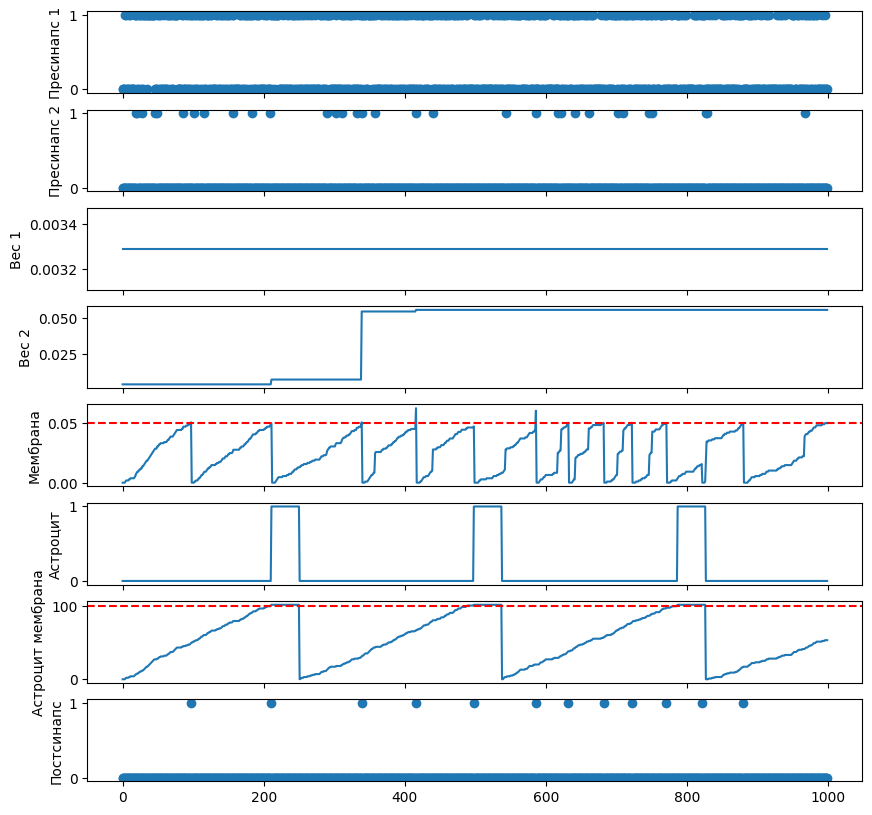

In [19]:
# запись веса 1
BL, WL = 0, 0
device.set_mvm()
_, weight_history, _ = device.write_weight(BL, WL, 0.0)
print(f'Weight {BL}, {WL} = {device.read_one_weight(BL, WL)[0]}')
device.set_wr()

# запись веса 2
device.set_mvm()
BL, WL = 1, 0
_, weight_history, _ = device.write_weight(BL, WL, 0.0)
print(f'Weight {BL}, {WL} = {device.read_one_weight(BL, WL)[0]}')
device.set_wr()

# входные данные
input_data_1 = np.random.binomial(1, 0.4, 1000)
input_data_2 = np.random.binomial(1, 0.03, 1000)

# хранилище выходных данных
output_data = []

# нейрон
neuron = LIFNeuron(device, 0, 2)

# настройка нейрона
neuron.change_trace_deep(4)
neuron.synapses[0].lock_stdp = True # запретим одному синапсу обновляться

# астроцит
astrocyte = Astrocyte()
astrocyte.set_controlled_membrains([neuron, ])

# рабочий цикл
for item in zip(input_data_1, input_data_2):
    astrocyte.set_input_spikes([item[0]])
    output_data.append(neuron.set_input_spike(np.array([item[0], item[1]])))

# отрисовка
fig, ax = plt.subplots(8, figsize=(10,10), sharex=True)

ax[0].plot(input_data_1, 'o')
ax[0].set_ylabel('Пресинапс 1')

ax[1].plot(input_data_2, 'o')
ax[1].set_ylabel('Пресинапс 2')

ax[2].plot(neuron.synapses[0].weight_history)
ax[2].set_ylabel('Вес 1')

ax[3].plot(neuron.synapses[1].weight_history)
ax[3].set_ylabel('Вес 2')

ax[4].plot(neuron.membrain_history)
ax[4].axhline(neuron.tresh, linestyle='--', color='red')
ax[4].set_ylabel('Мембрана')

ax[5].plot(astrocyte.active_history)
ax[5].set_ylabel('Астроцит')

ax[6].plot(astrocyte.membrain_history)
ax[6].axhline(astrocyte.tresh, linestyle='--', color='red')
ax[6].set_ylabel('Астроцит мембрана')

ax[-1].plot(output_data, 'o')
ax[-1].set_ylabel('Постсинапс')

plt.show()